# San Francisco Housing Prices Predict

Using a cleaned dataset of 1,000+ unique Craigslist apartment listings from October 2020, this project applies predictive modeling to analyze rental housing prices and guide prospective renters in evaluating market rates.

<img src='https://content.r9cdn.net/rimg/dimg/69/1b/cca1e76b-city-13852-1633ad11236.jpg?width=1366&height=768&crop=true' width='750'>

In [1]:
#Libraries
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
import warnings
warnings.filterwarnings("ignore")

# EDA

In [2]:
df=pd.read_csv('sf_clean.csv')

In [3]:
df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district
0,6800,1600.0,2.0,2.0,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0
1,3500,550.0,1.0,1.0,(a) in-unit,(a) both,(c) multi,(b) protected,7.0
2,5100,1300.0,2.0,1.0,(a) in-unit,(a) both,(c) multi,(d) no parking,7.0
3,9000,3500.0,3.0,2.5,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0
4,3100,561.0,1.0,1.0,(c) no laundry,(a) both,(c) multi,(d) no parking,7.0


In [4]:
df.tail()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district
984,3595,1200.0,2.0,1.0,(b) on-site,(c) cats,(c) multi,(d) no parking,9.0
985,4695,1700.0,3.0,2.0,(a) in-unit,(d) no pets,(c) multi,(d) no parking,7.0
986,1950,450.0,1.0,1.0,(c) no laundry,(d) no pets,(a) single,(c) off-street,3.0
987,3600,1100.0,3.0,1.0,(a) in-unit,(d) no pets,(c) multi,(d) no parking,8.0
988,3625,1032.0,2.0,2.0,(a) in-unit,(d) no pets,(c) multi,(b) protected,8.0


In [5]:
df.shape

(989, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 989 entries, 0 to 988
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          989 non-null    int64  
 1   sqft           989 non-null    float64
 2   beds           989 non-null    float64
 3   bath           989 non-null    float64
 4   laundry        989 non-null    object 
 5   pets           989 non-null    object 
 6   housing_type   989 non-null    object 
 7   parking        989 non-null    object 
 8   hood_district  989 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 69.7+ KB


In [7]:
df.isnull().sum()

price            0
sqft             0
beds             0
bath             0
laundry          0
pets             0
housing_type     0
parking          0
hood_district    0
dtype: int64

In [8]:
df.columns

Index(['price', 'sqft', 'beds', 'bath', 'laundry', 'pets', 'housing_type',
       'parking', 'hood_district'],
      dtype='object')

In [9]:
df.describe()

,price,sqft,beds,bath,hood_district
count,989.000000,989.000000,989.000000,989.000000,989.000000
mean,3595.035389,976.765420,1.679474,1.390293,7.052578
std,1546.222670,474.629798,1.076710,0.562714,2.404716
min,750.000000,150.000000,0.000000,1.000000,1.000000
25%,2650.000000,650.000000,1.000000,1.000000,6.000000
50%,3300.000000,900.000000,2.000000,1.000000,8.000000
75%,4242.000000,1200.000000,2.000000,2.000000,9.000000
max,19000.000000,3500.000000,6.000000,4.000000,10.000000


In [10]:
df.corr(numeric_only=True)

,price,sqft,beds,bath,hood_district
price,1.000000,0.835834,0.673328,0.691190,0.013010
sqft,0.835834,1.000000,0.765070,0.720929,-0.038425
beds,0.673328,0.765070,1.000000,0.629331,-0.109195
bath,0.691190,0.720929,0.629331,1.000000,0.022967
hood_district,0.013010,-0.038425,-0.109195,0.022967,1.000000


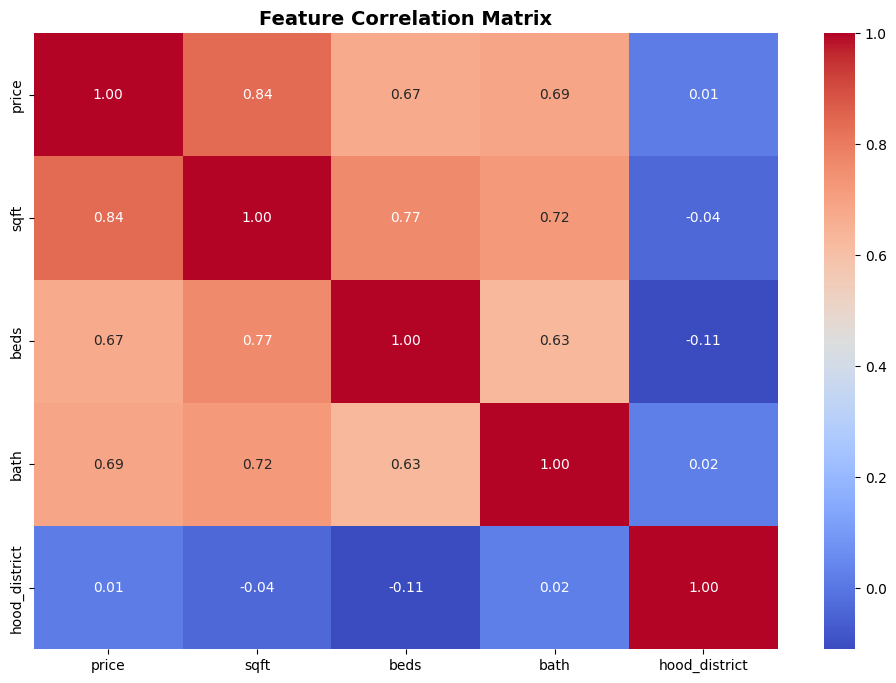

In [11]:
# Heatmap 
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')  
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

In [12]:
abs(df.corr(numeric_only=True)['price'].sort_values(ascending=False))

price            1.000000
sqft             0.835834
bath             0.691190
beds             0.673328
hood_district    0.013010
Name: price, dtype: float64

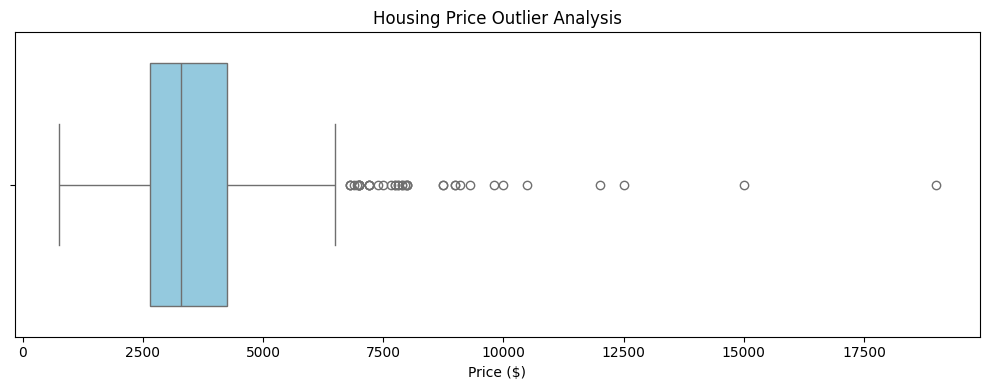

In [13]:
#outlier
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="price", color="skyblue")

plt.title("Housing Price Outlier Analysis", fontsize=12)
plt.xlabel("Price ($)")
plt.tight_layout()
plt.show()

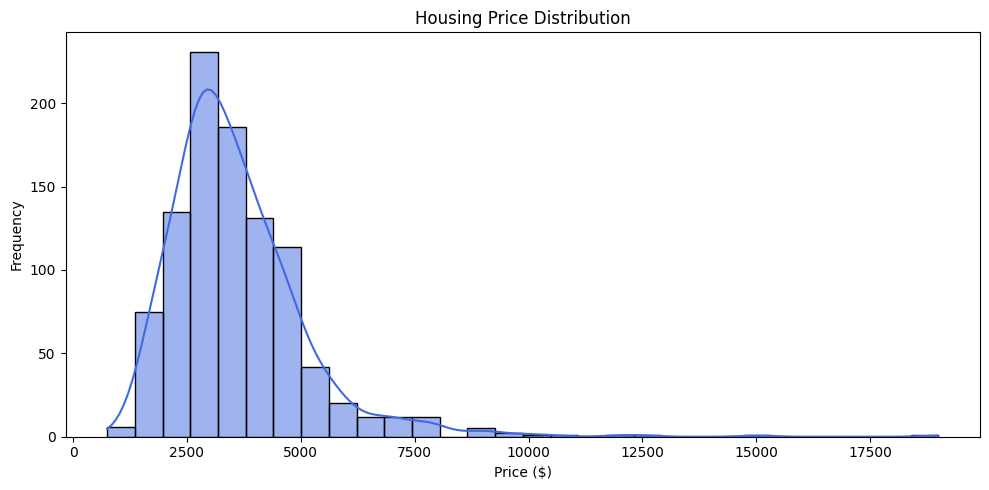

In [14]:
#Histogram & KDE (For Distribution Analysis)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="price", kde=True, color="royalblue", bins=30)

plt.title("Housing Price Distribution", fontsize=12)
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Feature Engineering

In [15]:
# 1. Ordinal Encoding for Laundry Facilities
# Mapping laundry types into numerical values based on convenience (In-unit > On-site > No laundry)
df.laundry = df.laundry.map(
    {"(a) in-unit": 2, "(b) on-site": 1, "(c) no laundry": 0}
)

In [16]:
# 2. String Cleaning for Category Columns
# Removing the leading category index labels (e.g., "(a) ", "(b) ") by slicing the first 4 characters
df.pets = df.pets.str[4:]
df.housing_type = df.housing_type.str[4:]

In [17]:
# 3. Ordinal Encoding for Parking Amenities
# Mapping parking options into numeric values ordered by property value/convenience level (Valet > Protected > Off-street > No parking)
df.parking = df.parking.map(
    {"(d) no parking": 0, "(c) off-street": 1, "(b) protected": 2, "(a) valet": 3}
)

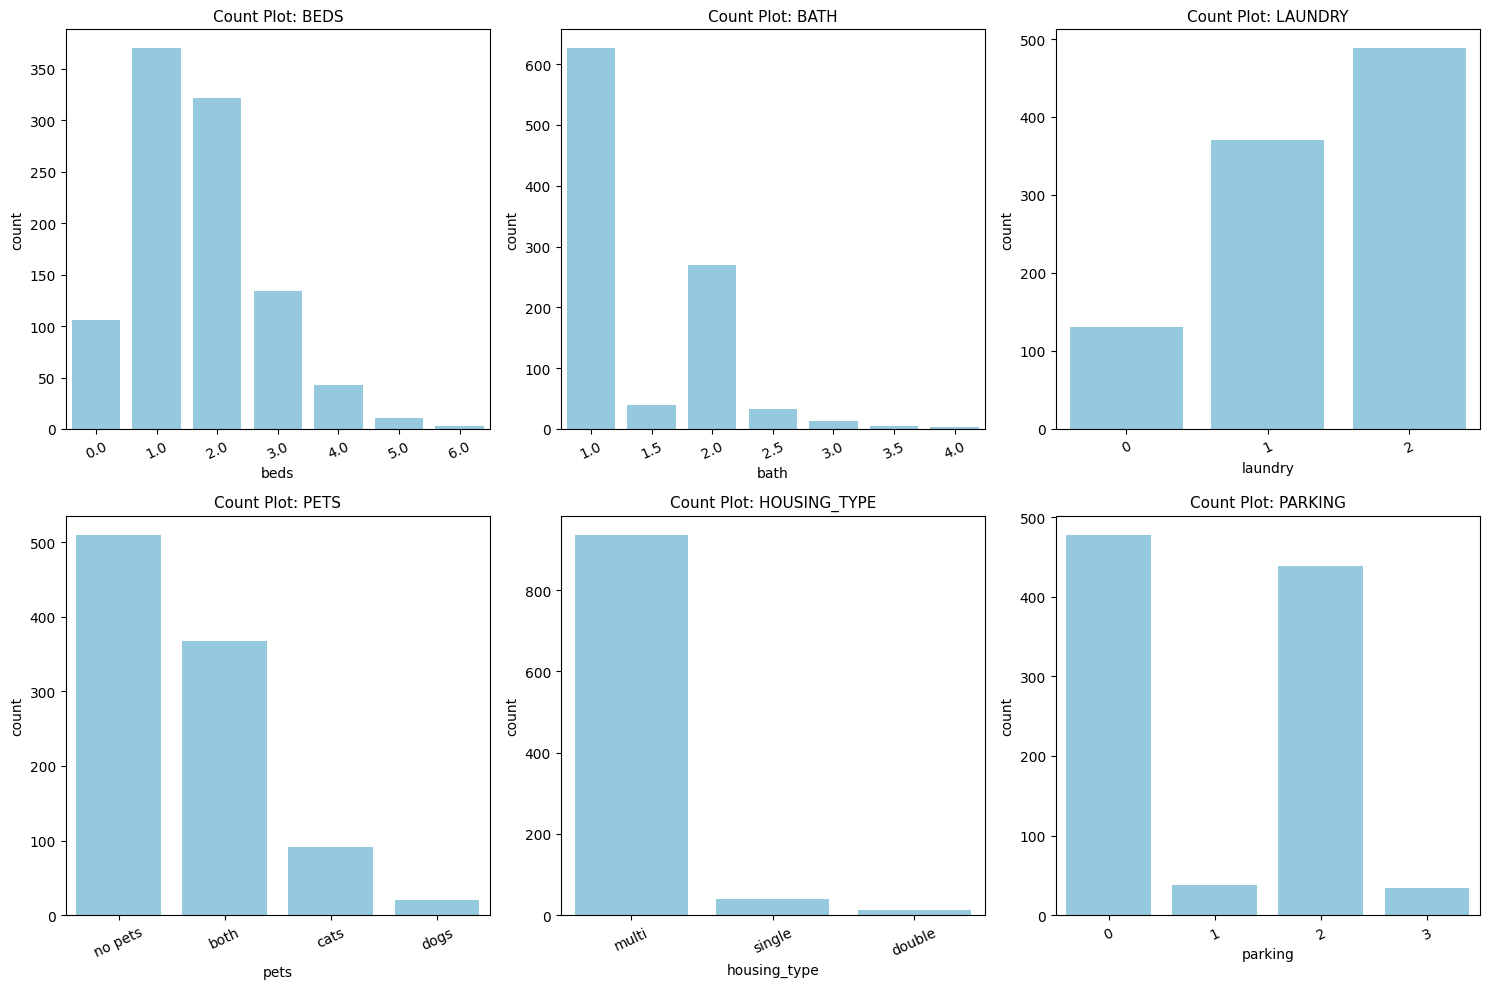

In [18]:
columns = ['beds', 'bath', 'laundry', 'pets', 'housing_type', 'parking']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Flatten axes array for simple 1D iteration
for col, ax in zip(columns, axes.flatten()):
    sns.countplot(data=df, x=col, ax=ax, color='skyblue')
    ax.set_title(f'Count Plot: {col.upper()}', fontsize=11)
    ax.tick_params(axis='x', rotation=25)  # Prevents overlapping text

plt.tight_layout()
plt.show()

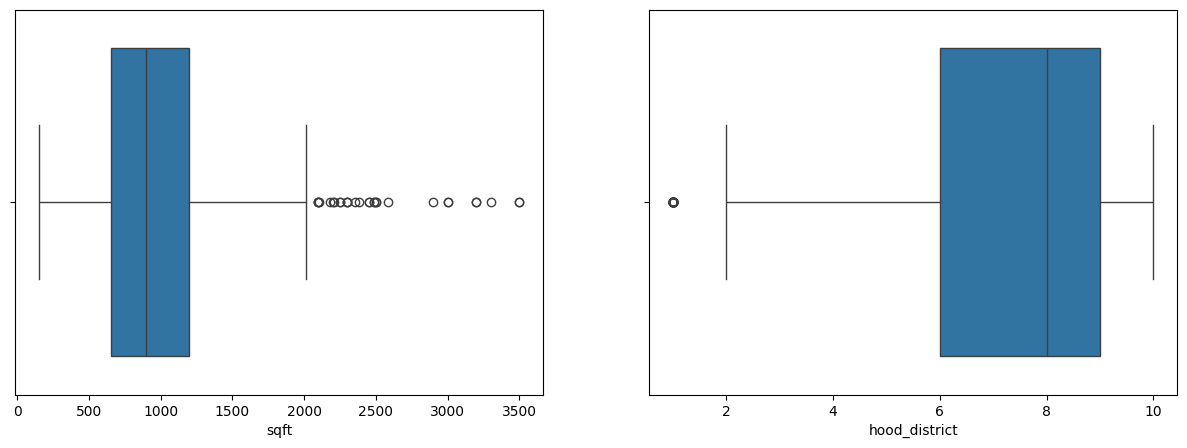

In [19]:
# Plot infos about entries
fig = plt.figure(figsize=(15, 5))
fig.add_subplot(1, 2, 1)
sns.boxplot(x=df['sqft'])
fig.add_subplot(1, 2, 2)
sns.boxplot(x=df['hood_district']);

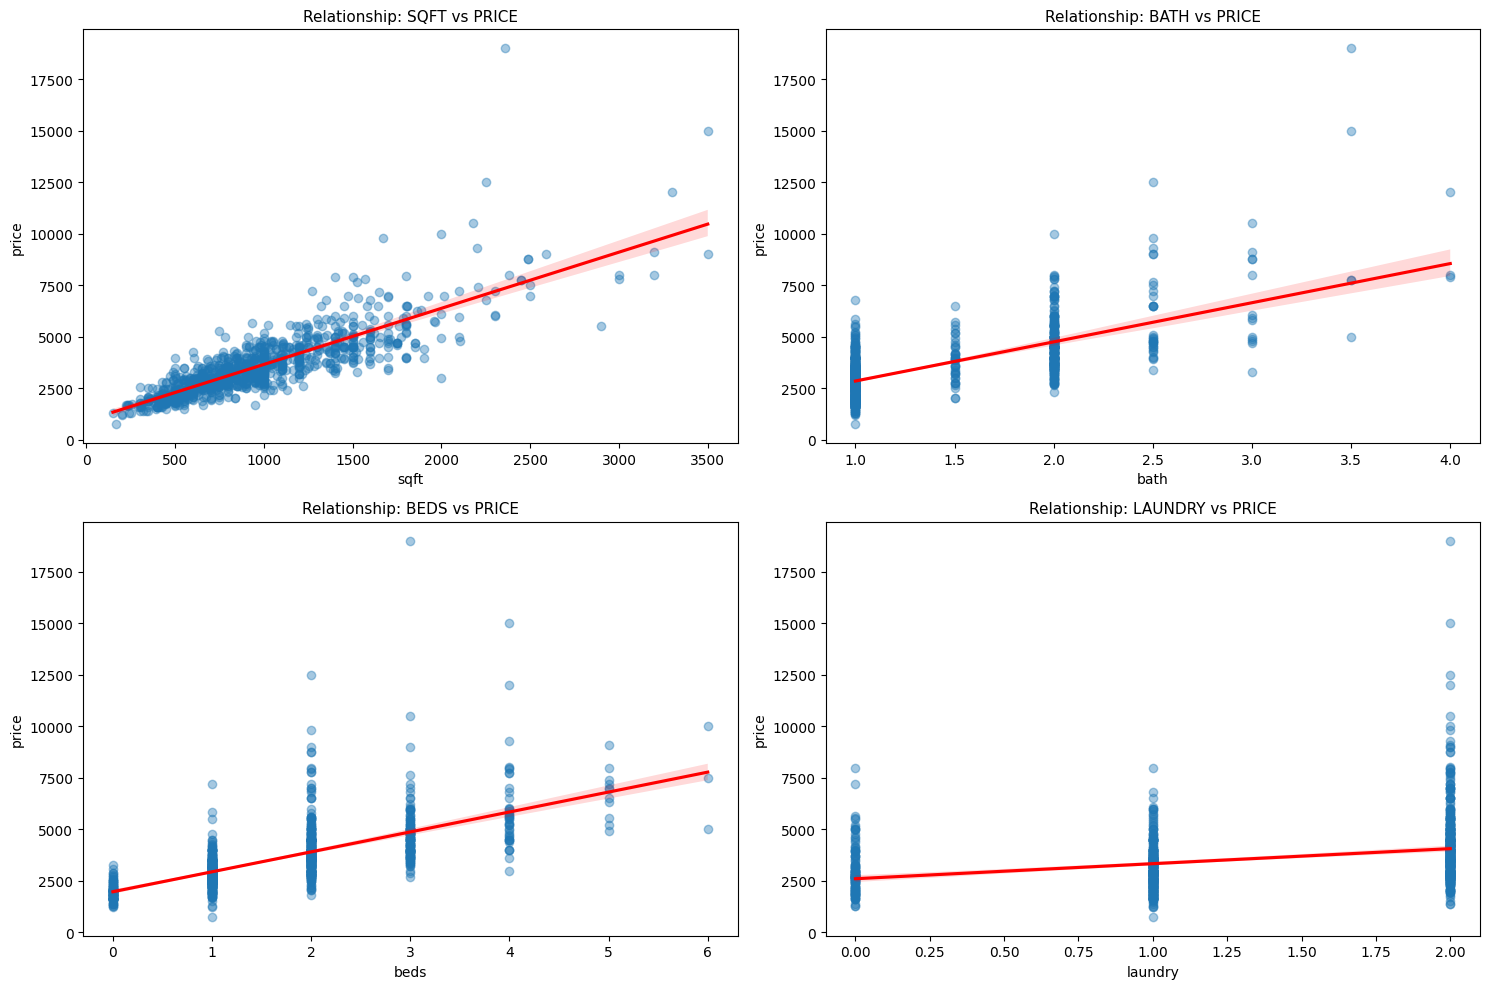

In [20]:
features = ['sqft', 'bath', 'beds', 'laundry']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for feature, ax in zip(features, axes.flatten()):
    # regplot trend
    sns.regplot(
        data=df, 
        x=feature, 
        y='price', 
        ax=ax, 
        scatter_kws={'alpha': 0.4}, 
        line_kws={'color': 'red'}
    )
    ax.set_title(f'Relationship: {feature.upper()} vs PRICE', fontsize=11)

plt.tight_layout()
plt.show()

In [21]:
# Pass numeric_only=True to exclude string/text columns
outliers = df.quantile(0.97, numeric_only=True)

# Filter the DataFrame
df = df[df['price'] < outliers['price']]

In [22]:
df["beds"]=df["beds"]**2
df["bath"]=df["bath"]**2
df["sqft"]=df["sqft"]**2

### Modeling

In [23]:
x,y=df.drop("price",axis=1),df[["price"]] 
x=pd.get_dummies(x,drop_first=True) 
x=scaler.fit_transform(x)

In [24]:
def regression_funct(x,y):
    #importing Regression libraries
    from sklearn.linear_model import LinearRegression
    from sklearn.linear_model import Ridge,Lasso
    from sklearn.linear_model import ElasticNet
    from sklearn.tree import ExtraTreeRegressor
    from sklearn.ensemble import GradientBoostingRegressor
    from sklearn.neighbors import KNeighborsRegressor
    from xgboost import XGBRegressor
    
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
    
    # split the data in Train and Test 
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

    L=LinearRegression()
    R=Ridge()
    Lass=Lasso()
    E=ElasticNet()
    ExTree=ExtraTreeRegressor()
    GBR=GradientBoostingRegressor()
    KN=KNeighborsRegressor()
    XGBC= XGBRegressor()
    
    algos=[L,R,Lass,E,ExTree,GBR,KN,XGBC]
    algo_names=['LinearRegression','Ridge','Lasso','ElasticNet','ExtraTreeRegressor','GradientBoostingRegressor','KNeighborsRegressor','XGBRegressor']
    r_squared=[]
    rmse=[]
    mae=[]
    
    result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names) # create df with results
    
    for item in algos: # fit and predict model with all algos and append the results in their lists
        item.fit(x_train,y_train)
        item.predict(x_test)
        r_squared.append(r2_score(y_test,item.predict(x_test)))
        rmse.append((mean_squared_error(y_test,item.predict(x_test)))**.5)
        mae.append(mean_absolute_error(y_test,item.predict(x_test)))
        
    result.R_Squared=r_squared
    result.RMSE=rmse
    result.MAE=mae
        
    return result.sort_values('R_Squared',ascending=False)

In [25]:
regression_funct(x,y)

,R_Squared,RMSE,MAE
GradientBoostingRegressor,0.800640,523.799695,398.102270
XGBRegressor,0.766706,566.628736,436.597931
LinearRegression,0.721432,619.172663,486.378055
Lasso,0.719271,621.570190,488.349973
Ridge,0.708162,633.749367,501.419824
KNeighborsRegressor,0.580482,759.838765,578.651042
ExtraTreeRegressor,0.522995,810.228921,616.986979
ElasticNet,0.128700,1095.040656,856.248284


In conclusion, the developed machine learning model successfully predicts San Francisco rental housing prices with an $R^2$ score of approximately 0.80. Key features such as square footage, number of bathrooms, and parking availability emerged as the primary drivers of rental valuations in the San Francisco market.